In [2]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
# -------- Set Global Seed --------
def set_global_seed(seed_value=42):
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_value)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_global_seed(42)

# Thiết lập thiết bị chạy (GPU nếu có, ngược lại là CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


In [3]:
# -------- Custom Layer: CHỈ Binarize Weight --------
class BinaryWeightConv2d(nn.Conv2d):
    def forward(self, input):
        # 1. Binarize weight: Ép trọng số kernel về 1.0 hoặc -1.0
        w_bin = torch.where(self.weight >= 0, 
                            torch.tensor(1.0, device=self.weight.device), 
                            torch.tensor(-1.0, device=self.weight.device))
        
        # 2. Straight-Through Estimator (STE) để tính gradient
        # .detach() trong PyTorch hoạt động giống tf.stop_gradient()
        w_bin = self.weight + (w_bin - self.weight).detach()
        
        # 3 & 4. Thực hiện phép chập (Convolution) với trọng số nhị phân và Bias
        return F.conv2d(input, w_bin, self.bias, self.stride,
                        self.padding, self.dilation, self.groups)


In [4]:
# -------- Load & Prepare MNIST --------
BINARIZE_INPUT = False 

# Khởi tạo các phép biến đổi ảnh
transform_list = [transforms.ToTensor()] # Đã bao gồm việc chuẩn hóa về [0, 1]

if BINARIZE_INPUT:
    print("Đang binarize dữ liệu ảnh đầu vào...")
    class BinarizeTransform:
        def __call__(self, x):
            return torch.where(x > 0.5, torch.tensor(1.0), torch.tensor(-1.0))
    transform_list.append(BinarizeTransform())

transform = transforms.Compose(transform_list)


In [5]:
# Tải dữ liệu
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# -------- Tham số huấn luyện --------
my_learning_rate = 0.001
my_epochs = 7
my_batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=my_batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=my_batch_size, shuffle=False)

In [6]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()
        # SỬ DỤNG nn.Conv2d CHUẨN THAY VÌ LỚP NHỊ PHÂN
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.flatten = nn.Flatten()
        
        # Tính toán kích thước đầu vào cho lớp Dense (Linear)
        self.fc1 = nn.Linear(32 * 13 * 13, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)        
        x = self.pool(x)
        x = self.flatten(x)
        x = self.fc1(x)
        return x             

model = BaselineCNN().to(device)

In [7]:
# -------- Optimizer & Loss --------
# Trong PyTorch, CrossEntropyLoss nhận trực tiếp logits (đầu ra chưa qua softmax)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=my_learning_rate)

# Lịch sử huấn luyện để vẽ biểu đồ
history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}

In [8]:
print("Training BASELINE CNN (Float Weights & Float Activations)...")
for epoch in range(my_epochs):
    # --- Huấn luyện ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    history['loss'].append(epoch_loss)
    history['accuracy'].append(epoch_acc)
    
    # --- Đánh giá (Validation) ---
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
    epoch_val_loss = val_loss / total
    epoch_val_acc = correct / total
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_acc)
    
    print(f"Epoch {epoch+1}/{my_epochs} - loss: {epoch_loss:.4f} - accuracy: {epoch_acc:.4f} - val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f}")


Training BASELINE CNN (Float Weights & Float Activations)...
Epoch 1/7 - loss: 0.2076 - accuracy: 0.9406 - val_loss: 0.0830 - val_accuracy: 0.9744
Epoch 2/7 - loss: 0.0728 - accuracy: 0.9782 - val_loss: 0.0576 - val_accuracy: 0.9822
Epoch 3/7 - loss: 0.0557 - accuracy: 0.9836 - val_loss: 0.0600 - val_accuracy: 0.9802
Epoch 4/7 - loss: 0.0445 - accuracy: 0.9869 - val_loss: 0.0514 - val_accuracy: 0.9827
Epoch 5/7 - loss: 0.0372 - accuracy: 0.9885 - val_loss: 0.0556 - val_accuracy: 0.9814
Epoch 6/7 - loss: 0.0311 - accuracy: 0.9904 - val_loss: 0.0487 - val_accuracy: 0.9835
Epoch 7/7 - loss: 0.0265 - accuracy: 0.9919 - val_loss: 0.0532 - val_accuracy: 0.9843


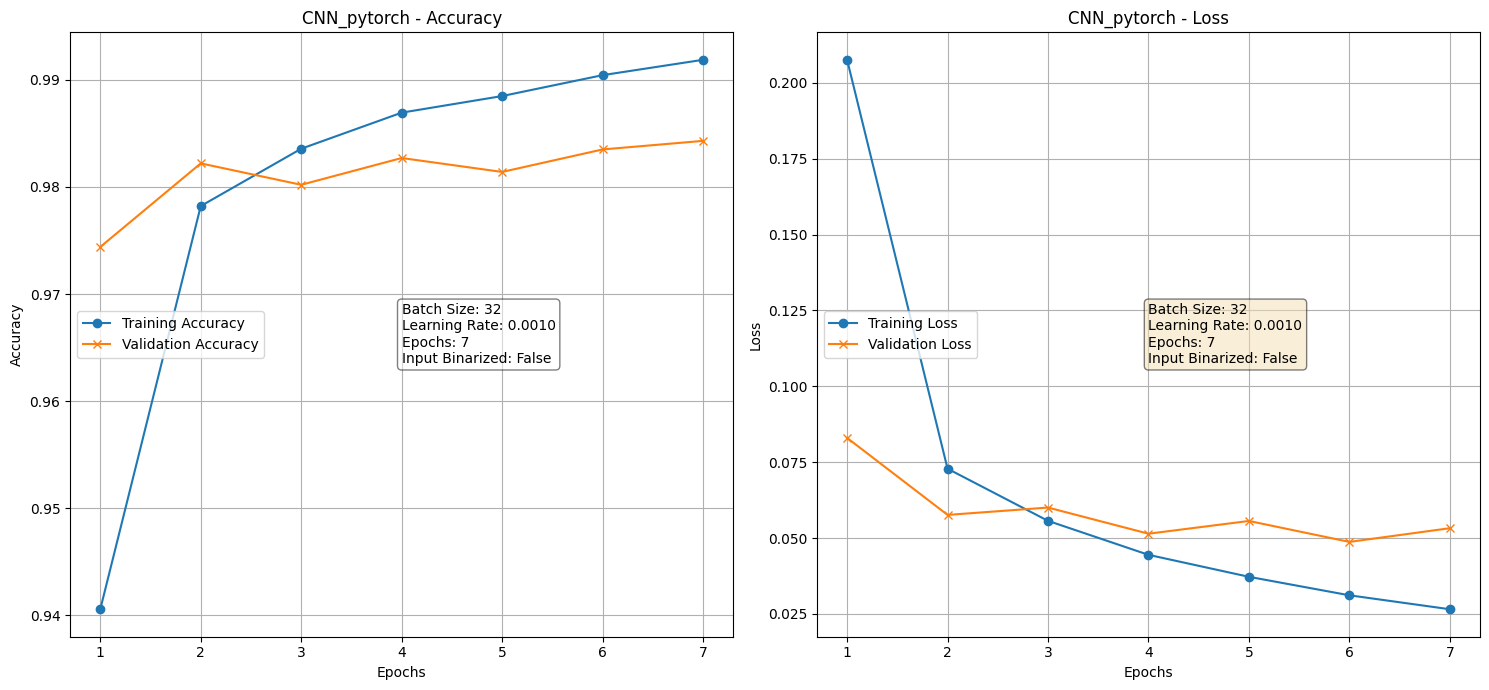

In [9]:
# -------- Plotting --------
epochs_range = range(1, my_epochs + 1)
info_text = f'Batch Size: {my_batch_size}\nLearning Rate: {my_learning_rate:.4f}\nEpochs: {my_epochs}\nInput Binarized: {BINARIZE_INPUT}'

plt.figure(figsize=(15, 7))

# --- Biểu đồ Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(epochs_range, history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('CNN_pytorch - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='center left')
plt.grid(True)
plt.text(0.5, 0.5, info_text, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

# --- Biểu đồ Loss ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['loss'], label='Training Loss', marker='o')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', marker='x')
plt.title('CNN_pytorch - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='center left')
plt.grid(True)
plt.text(0.5, 0.5, info_text, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='center', horizontalalignment='left',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()